<a href="https://colab.research.google.com/github/Prajnaa002/Applied_Machine_Learning/blob/main/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Python example: simple linear regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
#input:study hours
X = np.array([1,2,3,4,5]).reshape(-1,1) # if -1 is kept in row can fill the entries as it is and column is single column
X

array([[1],
       [2],
       [3],
       [4],
       [5]])

In [ ]:
#output: marks
y=np.array([40,50,50,60,70])
y

array([40, 50, 50, 60, 70])

In [ ]:
#create and train the model
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
#display the regression parameters
print("Intercept: ",model.intercept_)
print("Slope: ", model.coef_[0])

Intercept:  33.0
Slope:  7.0


In [ ]:
#predict msrks for six study hours
new_data = np.array([[6]])
predicted_mark = model.predict(new_data)

In [ ]:
print("Predicted mark: ", predicted_mark[0])

Predicted mark:  75.0


In [ ]:
# predictions for the original observations
y_pred = model.predict(X)
y_pred

array([40., 47., 54., 61., 68.])

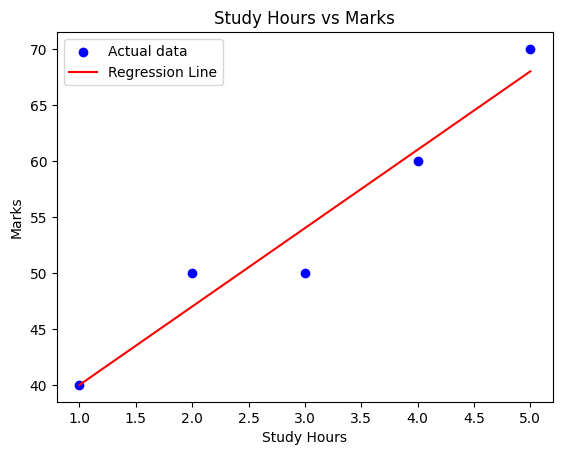

In [ ]:
#plot data and regression line
plt.scatter(X,y,color='blue', label = "Actual data")
plt.plot(X,y_pred,color='red', label = "Regression Line")
plt.xlabel('Study Hours')
plt.ylabel('Marks')
plt.title('Study Hours vs Marks')
plt.legend()
plt.show()

Evaluating python model

In [ ]:
import numpy as np
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
mae = mean_absolute_error(y,y_pred)
mse = mean_squared_error(y,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y,y_pred)

In [ ]:
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("Root Mean Squared Error: ",rmse)
print("R-Squared: ",r2)

Mean Absolute Error:  2.0
Mean Squared Error:  6.0
Root Mean Squared Error:  2.449489742783178
R-Squared:  0.9423076923076923


Train-test split example

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
data = {
  "Study Hours" : [1,2,3,4,5,6,7,8,9,10],
  "Marks" : [32,38,43,50,54,61,68,73,81,88]
}


In [ ]:
df = pd.DataFrame(data)
df

,Study Hours,Marks
0,1,32
1,2,38
2,3,43
3,4,50
4,5,54
5,6,61
6,7,68
7,8,73
8,9,81
9,10,88


In [ ]:
X= df[["Study Hours"]]
y= df[["Marks"]]
X

,Study Hours
0,1
1,2
2,3
3,4
4,5
5,6
6,7
7,8
8,9
9,10


In [ ]:
y

,Marks
0,32
1,38
2,43
3,50
4,54
5,61
6,68
7,73
8,81
9,88


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([[80.19827586],
       [37.05172414]])

In [ ]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("Actual values:", y_test.values.flatten())
print("Predicted values:", y_pred.flatten())

Intercept: [24.72413793]
Slope: [6.1637931]
Actual values: [81 38]
Predicted values: [80.19827586 37.05172414]


In [ ]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.875
MSE: 0.7709943519619504
RMSE: 0.8780628405541089
R2: 0.9983320836085193


Multiple linear regression in Python

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = {
    "Study Hours" : [2,3,4,5,6,7,8,9],
    "Study Hours/Week" : [14,21,28,35,42,49,56,63],
    "Attendance" : [60,65,70,75,80,85,90,95],
    "Assignment_Score" : [50,55,58,65,70,74,80,88],
    "Final_Marks" : [42,48,54,61,67,73,81,89]
}

In [ ]:
df= pd.DataFrame(data)
df

,Study Hours,Study Hours/Week,Attendance,Assignment_Score,Final_Marks
0,2,14,60,50,42
1,3,21,65,55,48
2,4,28,70,58,54
3,5,35,75,65,61
4,6,42,80,70,67
5,7,49,85,74,73
6,8,56,90,80,81
7,9,63,95,88,89


In [ ]:
X = df[["Study Hours","Study Hours/Week","Attendance","Assignment_Score"]]
y = df[["Final_Marks"]]
X

,Study Hours,Study Hours/Week,Attendance,Assignment_Score
0,2,14,60,50
1,3,21,65,55
2,4,28,70,58
3,5,35,75,65
4,6,42,80,70
5,7,49,85,74
6,8,56,90,80
7,9,63,95,88


In [ ]:
y

,Final_Marks
0,42
1,48
2,54
3,61
4,67
5,73
6,81
7,89


In [ ]:
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
print("Intercept: ", model.intercept_)

Intercept:  [-6.85285285]


In [ ]:
coefficient_table = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": model.coef_[0]
    }
)

In [ ]:
print(coefficient_table)

            Feature  Coefficient
0       Study Hours     0.045556
1  Study Hours/Week     0.318889
2        Attendance     0.227778
3  Assignment_Score     0.608108


In [ ]:
new_student = pd.DataFrame({
    "Study Hours": [6],
    "Study Hours/Week": [42],
    "Attendance": [82],
    "Assignment_Score": [72]
})

In [ ]:
prediction = model.predict(new_student)
print("Predicted Final Marks:", prediction[0])

Predicted Final Marks: [69.27537538]


In [ ]:
# study hrs per week
#convert to csv file

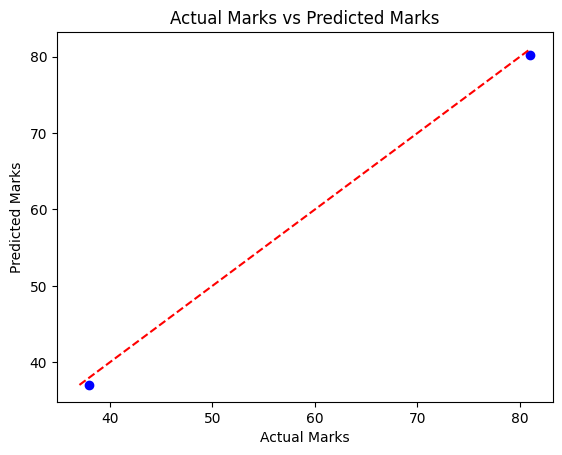

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color = "blue")
minimum = min(y_test.values.min(), y_pred.min())
maximum = max(y_test.values.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--")
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title('Actual Marks vs Predicted Marks')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.to_csv("drive/My Drive/Colab Notebooks/Datasets/Student.csv", index=False) #convert to csv

residual plot

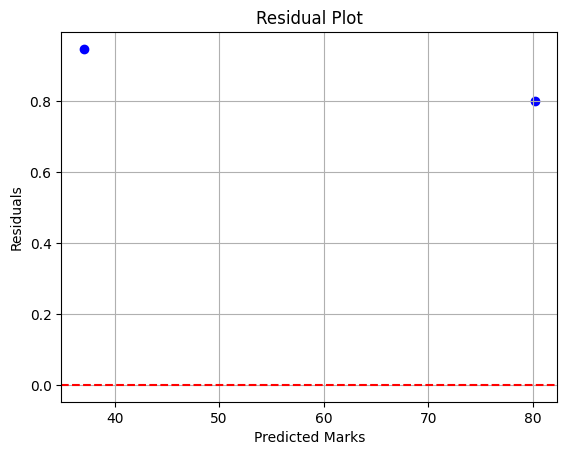

In [ ]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, color = "blue")
plt.axhline(y = 0, color = "red", linestyle = "--")
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title('Residual Plot')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
data = {
    "Size" : [800,1000,1200,1500,1800],
    "Location" : ["Rural", "Urban", "Rural", "Urban", "Urban"],
    "Price" : [30,50,42,72,85]
}

df = pd.DataFrame(data)
df

,Size,Location,Price
0,800,Rural,30
1,1000,Urban,50
2,1200,Rural,42
3,1500,Urban,72
4,1800,Urban,85


In [ ]:
from numpy._core.multiarray import dtype
df_encoded = pd.get_dummies(
    df,
    columns = ["Location"],
    drop_first = True,
    dtype = int
  )
df_encoded

,Size,Price,Location_Urban
0,800,30,0
1,1000,50,1
2,1200,42,0
3,1500,72,1
4,1800,85,1
